##Imports

In [1]:
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import BertTokenizer, BertForSequenceClassification, BertForQuestionAnswering
from transformers import Trainer, TrainingArguments, pipeline

##Sentiment Dataset

In [2]:
dataset = load_dataset("imdb")

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(x):
    return tokenizer(x["text"], truncation=True, padding="max_length", max_length=128)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("label", "labels")
dataset.set_format(type="torch", columns=["input_ids","attention_mask","labels"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

##Sentiment Model

In [3]:
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


##Training Setup

In [4]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"].shuffle(seed=42).select(range(2000)),
    eval_dataset=dataset["test"].select(range(500)),
)

##Train Sentiment

In [5]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,0.698389
100,0.535561
150,0.433539
200,0.487885
250,0.369372


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=250, training_loss=0.5049492416381836, metrics={'train_runtime': 3224.4627, 'train_samples_per_second': 0.62, 'train_steps_per_second': 0.078, 'total_flos': 131555527680000.0, 'train_loss': 0.5049492416381836, 'epoch': 1.0})

##Loss Plot

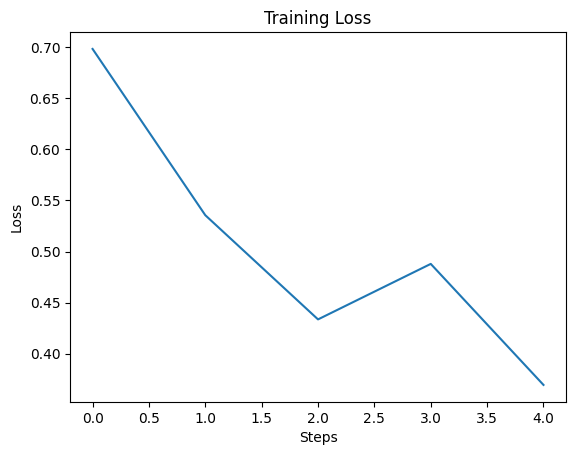

In [6]:
logs = trainer.state.log_history
losses = [x["loss"] for x in logs if "loss" in x]

plt.plot(losses)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

##Sentiment Prediction

In [7]:
samples = ["Great movie", "Worst film ever", "Not bad"]

for s in samples:
    inputs = tokenizer(s, return_tensors="pt")
    outputs = model(**inputs)
    pred = torch.argmax(outputs.logits, dim=1).item()
    print(s, "->", "Positive" if pred==1 else "Negative")

Great movie -> Positive
Worst film ever -> Negative
Not bad -> Negative


##Load SQuAD

In [8]:
dataset_qa = load_dataset("squad")

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

##Tokenize + Labels

In [14]:
def preprocess(x):
    inputs = tokenizer(
        x["question"],
        x["context"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

    start_positions = []
    end_positions = []

    for ans in x["answers"]:
        if len(ans["answer_start"]) > 0:
            start = ans["answer_start"][0]
            end = start + len(ans["text"][0])
        else:
            start, end = 0, 0

        start_positions.append(start)
        end_positions.append(end)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions

    return inputs

dataset_qa = dataset_qa.map(preprocess, batched=True)
dataset_qa.set_format(type="torch", columns=[
    "input_ids", "attention_mask", "start_positions", "end_positions"
])

Map:   0%|          | 0/87599 [00:00<?, ? examples/s]

Map:   0%|          | 0/10570 [00:00<?, ? examples/s]

##QA Model

In [15]:
model_qa = BertForQuestionAnswering.from_pretrained("bert-base-uncased")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForQuestionAnswering LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
qa_outputs.bias                            | MISSING    | 
qa_outputs.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized beca

##QA Training

In [16]:
training_args_qa = TrainingArguments(
    output_dir="./qa_results",
    per_device_train_batch_size=4,
    num_train_epochs=1
)

trainer_qa = Trainer(
    model=model_qa,
    args=training_args_qa,
    train_dataset=dataset_qa["train"].select(range(2000)),
)